GET THE KAGGLE API TOKEN FROM THE ENV

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

username = os.getenv("KAGGLE_USERNAME")
key = os.getenv("KAGGLE_TOKEN")

print(username)
print("Key loaded:", key is not None)

rajagurur2004
Key loaded: True


In [4]:
import os

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_TOKEN"] = key

In [5]:
!kaggle datasets list -s "brain tumor"

ref                                                       title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jakeshbohaju/brain-tumor                                  Brain Tumor                                          14629270  2020-07-26 01:52:35.323000          27410        349  0.9411765        
masoudnickparvar/brain-tumor-mri-dataset                  Brain Tumor MRI Dataset                             164670110  2026-02-13 19:25:36.413000         201799       1367  0.875            
sartajbhuvaji/brain-tumor-classification-mri              Brain Tumor Classification (MRI)                     91002358  2025-08-12 15:45:16.840000         101952        855  0.875            
jillanisofttech/brain-tumor        

In [7]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100%|███████████████████████████████████████| 157M/157M [00:11<00:00, 14.7MB/s]



In [8]:
!ls

anydesk_8.0.4-1_x86_64.rpm
bird.jpg
bird_or_not
brain-tumor-mri-dataset.zip
forest.jpg
is-it-a-bird-creating-a-model-from-your-own-data.ipynb
readme.md
requirements.txt
tumor_model.ipynb
tumors


In [9]:
import zipfile

zip_path = "brain-tumor-mri-dataset.zip"
extract_path = "tumors"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
from pathlib import Path

path = Path("tumors")

for item in path.iterdir():
    print(item)

tumors/Testing
tumors/Training


NOW ITS TIME TO CREATE THE MODEL AND TRAIN IT

In [1]:
from fastai.vision.all import *
from pathlib import Path

# Fix dark mode rendering of fastprogress tables
try:
    from IPython.display import HTML, display
    display(HTML('''
    <style>
        table.fastprogress thead tr,
        table.fastprogress tbody tr:nth-of-type(even) {
            background: rgba(128, 128, 128, 0.15) !important;
        }
    </style>
    '''))
except ImportError:
    pass


In [2]:
path = Path("tumors")
train_path = path / "Training"
test_path = path / "Testing"

In [3]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),

    get_items=get_image_files,

    get_y=parent_label,

    splitter=GrandparentSplitter(
        train_name="Training",
        valid_name="Testing"
    ),

    item_tfms=Resize(224),

    batch_tfms=aug_transforms()
).dataloaders(path, bs=32)

['glioma', 'meningioma', 'notumor', 'pituitary']

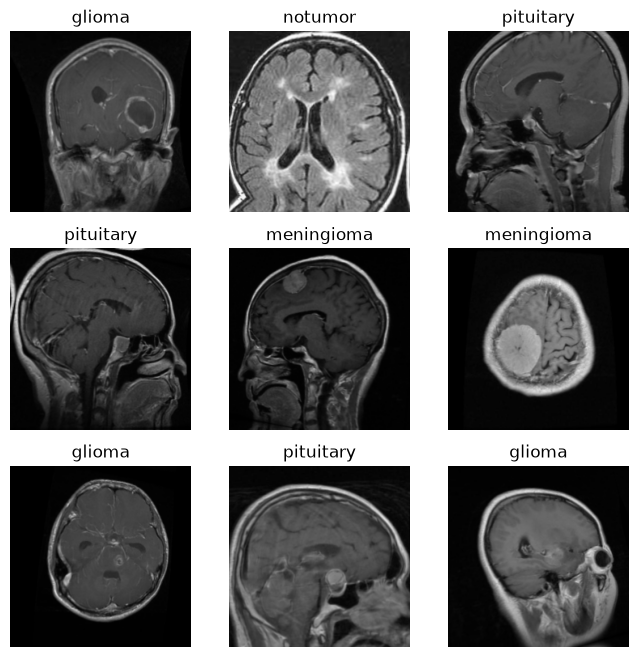

In [4]:
dls.show_batch(max_n=9, figsize=(8,8))
dls.vocab

In [6]:
learn = vision_learner(
    dls,
    resnet18,
    metrics=accuracy
)

learn.fine_tune(5)

epoch,train_loss,valid_loss,accuracy,time
0,0.635272,0.588153,0.830000,00:26


epoch,train_loss,valid_loss,accuracy,time
0,0.347224,0.439676,0.884375,00:34
1,0.213799,0.399644,0.913750,00:34
2,0.141734,0.416388,0.917500,00:34
3,0.090193,0.340304,0.937500,00:34
4,0.059107,0.332953,0.938750,00:34


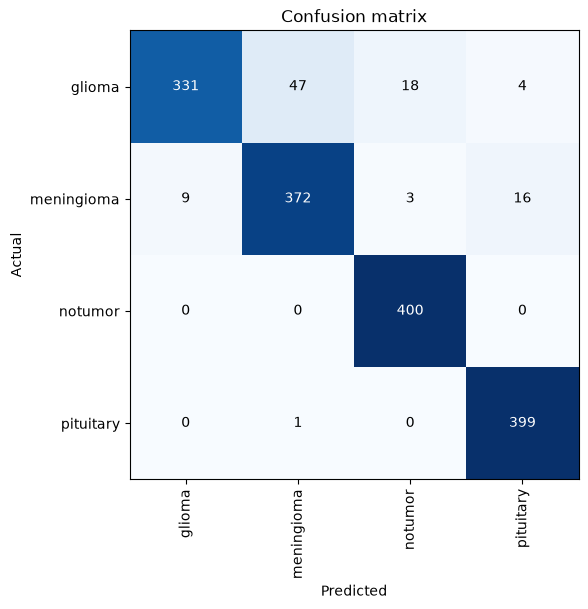

In [7]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(6,6))

In [13]:
img = PILImage.create("tumors/Testing/meningioma/Te-aug-me_1.jpg")

tumor_type, pred_idx, probs = learn.predict(img)

print(f"This is a: {tumor_type}.")
print()

print(f"Probability it's Glioma      : {probs[0]:.4f} ({probs[0]*100:.2f}%)")
print(f"Probability it's Meningioma  : {probs[1]:.4f} ({probs[1]*100:.2f}%)")
print(f"Probability it's No Tumor    : {probs[2]:.4f} ({probs[2]*100:.2f}%)")
print(f"Probability it's Pituitary   : {probs[3]:.4f} ({probs[3]*100:.2f}%)")

This is a: meningioma.

Probability it's Glioma      : 0.0009 (0.09%)
Probability it's Meningioma  : 0.9978 (99.78%)
Probability it's No Tumor    : 0.0000 (0.00%)
Probability it's Pituitary   : 0.0013 (0.13%)
